# Multi-layer Perceptron

In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns

# Load tips dataset
tips = sns.load_dataset('tips')

# Preprocessing
# Converting categorical variables to dummy variables
tips = pd.get_dummies(tips, drop_first=True)

# Selecting features and target (predicting 'tip' based on other features)
X = tips.drop('tip', axis=1)
y = tips['tip']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Standardizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', 
                          input_shape=(X_train.shape[1],)), # Input layer
    
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
print('Mean Squared Error: ', loss[0])

c:\Users\dell\miniconda3\envs\Deep_Learning\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 10.8894 - mae: 2.9917
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8.3423 - mae: 2.5397 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.2954 - mae: 2.2800 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9160 - mae: 1.8296
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8753 - mae: 1.3335
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9015 - mae: 1.0293
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3738 - mae: 0.9157
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6565 - mae: 0.9546 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2655 - mae: 0.8828
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3713 - mae: 0.8989
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3211 - mae: 0.8686
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1826 - mae: 0.8311
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms

- **Imports**: 
    - TensorFlow (`tensorflow`) for building and training the neural network.
    - `train_test_split` from `sklearn.model_selection` for splitting the dataset into training and testing sets.
    - `StandardScaler` from `sklearn.preprocessing` for standardizing the dataset.
    - `pandas` for data manipulation.
    - `seaborn` for loading the `tips` dataset.

- **Dataset**: 
    - The `tips` dataset is loaded using `seaborn.load_dataset('tips')`.
    - Categorical variables are converted to dummy variables using `pd.get_dummies()`.

- **Features and Target**:
    - Features (`X`) are all columns except `tip`.
    - Target (`y`) is the `tip` column.

- **Data Splitting**:
    - The dataset is split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets using an 80-20 split.

- **Data Standardization**:
    - The features are standardized using `StandardScaler`.

- **Model**:
    - A Sequential model is built with:
        - Input layer: Dense layer with 64 neurons and ReLU activation.
        - Hidden layer: Dense layer with 32 neurons and ReLU activation.
        - Output layer: Dense layer with 1 neuron for regression.

- **Compilation**:
    - The model is compiled with the Adam optimizer, Mean Squared Error loss, and Mean Absolute Error as a metric.

- **Training**:
    - The model is trained for 100 epochs with a batch size of 32.

- **Evaluation**:
    - The model is evaluated on the test set, and the Mean Squared Error is printed.

c:\Users\dell\miniconda3\envs\Deep_Learning\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


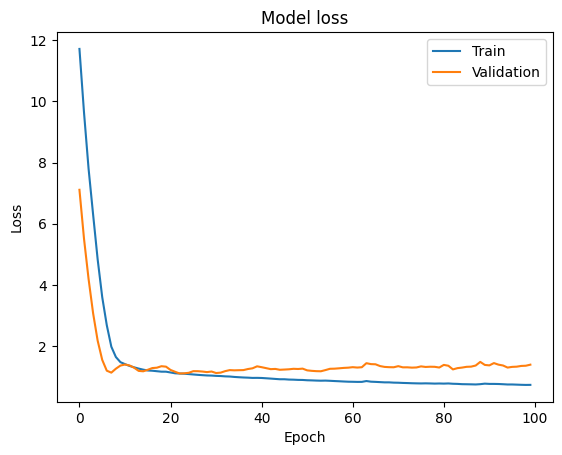

In [2]:
# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# train the model and plot the training and testing loss and accuracy at each epoc
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, validation_data=(X_test, y_test))

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

## Early Stopping of Epochs

c:\Users\dell\miniconda3\envs\Deep_Learning\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - loss: 11.7183 - val_loss: 6.0804
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 7.7484 - val_loss: 4.4718
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 6.6376 - val_loss: 3.1519
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 4.7851 - val_loss: 2.1251
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 3.5022 - val_loss: 1.4458
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 2.6714 - val_loss: 1.1317
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 1.5397 - val_loss: 1.0571
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 1.4193 - val_loss: 1.0819
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1.2770 - val_loss: 1.1036
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 1.2465 - val_loss: 1.0927
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.3416 - val_loss: 1.0834
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 1.3352 - val

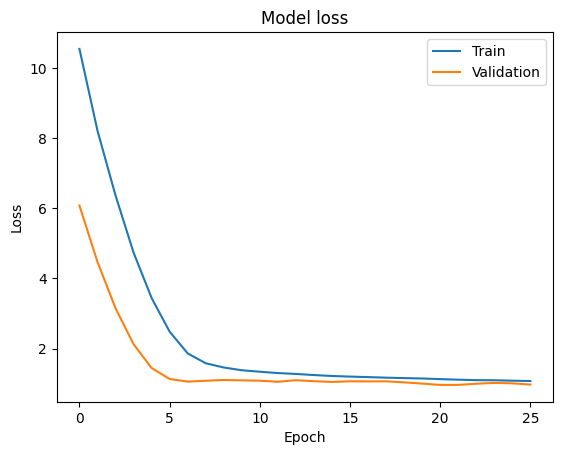

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define the callback function
early_stopping = EarlyStopping(patience=5)

# Train the model with the callback function
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# About the Author

<div style="background-color: #f8f9fa; border-left: 5px solid #28a745; padding: 20px; margin-bottom: 20px; border-radius: 5px;">
  <h2 style="color: #28a745; margin-top: 0; font-family: 'Poppins', sans-serif;">Muhammad Atif Latif</h2>
  <p style="font-size: 16px; color: #495057;">Data Scientist & Machine Learning Engineer</p>
  
  <p style="font-size: 15px; color: #6c757d; margin-top: 15px;">
    Passionate about building AI solutions that solve real-world problems. Specialized in machine learning, 
    deep learning, and data analytics with experience implementing production-ready models.
  </p>
</div>

## Connect With Me

<div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 15px;">
  <a href="https://github.com/m-Atif-Latif" target="_blank">
    <img src="https://img.shields.io/badge/GitHub-Follow-212121?style=for-the-badge&logo=github" alt="GitHub">
  </a>
  <a href="https://www.kaggle.com/matiflatif" target="_blank">
    <img src="https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle" alt="Kaggle">
  </a>
  <a href="https://www.linkedin.com/in/muhammad-atif-latif-13a171318" target="_blank">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-0077B5?style=for-the-badge&logo=linkedin" alt="LinkedIn">
  </a>
  <a href="https://x.com/mianatif5867" target="_blank">
    <img src="https://img.shields.io/badge/Twitter-Follow-1DA1F2?style=for-the-badge&logo=twitter" alt="Twitter">
  </a>
  <a href="https://www.instagram.com/its_atif_ai/" target="_blank">
    <img src="https://img.shields.io/badge/Instagram-Follow-E4405F?style=for-the-badge&logo=instagram" alt="Instagram">
  </a>
  <a href="mailto:muhammadatiflatif67@gmail.com">
    <img src="https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge&logo=gmail" alt="Email">
  </a>
</div>

---